# Skattning av vaccineffekt från en randomiserad studie via tid-till-första-infektion

## Sammanfattning

## Skattning av vaccineffekt från en randomiserad studie

En pivotal fas III-vaccinstudie randomiserar deltagare 1:1 till **vaccin** eller **placebo** och följer varje person fram till deras första laboratoriebekräftade infektion eller till administrativ censurering vid slutet av inkluderings- och uppföljningsfönstret. Det regulatoriska primära effektmåttet är **vaccineffekt (VE)**, definierat som `VE = 1 - hazard ratio (vaccine vs. placebo)`. Eftersom deltagare inkluderas enligt ett förskjutet schema och de flesta aldrig blir infekterade är data högercensurerade, och överlevnadsmetoder — inte enkla proportioner — ger den försvarbara skattningen.

Denna notebook arbetar igenom effektmåttet från början till slut på en syntetisk balanserad studie med **100 försökspersoner (50 vaccin, 50 placebo)**:

- **PROC FREQ** bygger fyrfältstabellen för attackfrekvens (arm mot infektionsstatus) med chi-två-test, relativ risk och riskdifferens — den beskrivande vyn av "rå VE" som en klinisk granskare ser först.
- **PROC MEANS** sammanfattar persontid (totala och genomsnittliga uppföljningsdagar) och de råa infektionsantalen per arm, vilket blottlägger den censureringsobalans som motiverar en tid-till-händelse-modell.
- **PROC LIFETEST** skattar Kaplan-Meier-överlevnadskurvorna per arm och kör homogenitetstesten **log-rank och Wilcoxon** — den ickeparametriska bekräftelsen att kurvorna separerar.
- **PROC PHREG** anpassar Cox proportionella hazardmodell justerad för ålder, kön och exponeringsrisk vid baslinjen, rapporterar hazardkvoten med dess 95-procentiga konfidensgränser, och **HAZARDRATIO**-satsen ramar in armkontrasten direkt. Den justerade VE:n avläses som `1 - HR`.

**Så tolkas resultatet.** I den verifierade körningen är den råa infektionsproportionen **64 % i placebo mot 30 % i vaccin** (chi-två p = 0.0007), log-rank-testet förkastar likhet mellan överlevnadskurvorna (χ² = 11.25, p = 0.0008), och den justerade Cox-hazardkvoten för vaccin mot placebo är **0.369** med ett 95 % KI på **(0.198, 0.687)** — helt under 1 — dvs. en skattad VE på ungefär **63 %** (`1 - 0.369`). Den övre HR-konfidensgränsen på 0.687 motsvarar en nedre effektgräns nära 31 %, vid kanten av den konventionella tröskeln på 30-50 % för licensiering av en så här liten studie. Ett yrke med hög exponering vid baslinjen ungefär tredubblar infektionshazarden (HR = 3.47, p < .0001), vilket bekräftar att kovariatjusteringen spelar roll; ålder och kön har gränsfallseffekter (p ≈ 0.06) som inte når signifikans på 0.05-nivån. Samstämmigheten mellan den råa fyrfältstabellen, de separerade KM-kurvorna och den justerade Cox-skattningen är precis den triangulering som en säkerhetsövervakningskommitté (Data Safety Monitoring Board) förväntar sig innan effekt kan fastställas.

*Endast syntetiska data — genererade inline med `streaminit`/`rand`; inga externa filer eller nätverk. Körs på klart under en minut.*

## Datakällor

**Syntetiskt dataset `trial`** — en rad per inkluderad deltagare, genererat inline i den första kodcellen (frö `20260605`). 100 försökspersoner, balanserade 1:1 (50 vaccin, 50 placebo), exponentiell tid-till-infektion med en ~70 % hazardreduktion i vaccinarmen, förskjuten inkludering och administrativ censurering vid slutet av ett 540-dagarsfönster.

| Variabel | Typ | Beskrivning |
|----------|------|-------------|
| `subjid` | Num | Försökspersonens identifierare (1-100) |
| `arm` | Char | Behandlingsarm: `Vaccine` eller `Placebo` |
| `arm_n` | Num | Numerisk armflagga (1 = vaccin, 0 = placebo) |
| `age` | Num | Ålder i år vid inkludering (18-85) |
| `sex` | Char | Kön: `F` eller `M` |
| `baseline_risk` | Num | Indikator för yrke med hög exponering (1 = ja) |
| `fu_days` | Num | Uppföljningstid i dagar till första infektion eller censurering |
| `infected` | Num | Händelseindikator: 1 = observerad infektion, 0 = censurerad |

# Skattning av vaccineffekt från en randomiserad studie

**Överlevnadsanalys av tid till första infektion**

Det primära effektmåttet i en vaccinstudie är **infektionshazarden** i vaccinarmen relativt placebo. Vi definierar

$$\text{VE} = 1 - \text{HR}_{\text{vaccine vs. placebo}}$$

Eftersom deltagare inkluderas enligt ett förskjutet schema och de flesta aldrig blir infekterade innan uppföljningen slutar är data högercensurerade: en enkel jämförelse av andelen infekterade slösar bort tidsinformationen och snedvrids av ojämn uppföljning. Vi bygger därför skattningen i tre lager — en rå fyrfältstabell för attackfrekvens, ickeparametriska Kaplan-Meier-kurvor med ett log-rank-test, och en justerad Cox proportionell hazardmodell — och kontrollerar att alla tre berättar samma historia.

Analysen använder **PROC FREQ**, **PROC MEANS**, **PROC LIFETEST** och **PROC PHREG**.

## 1. Generera den syntetiska studien

Vi simulerar en balanserad, 1:1-randomiserad studie med 100 försökspersoner (50 vaccin, 50 placebo — tilldelade efter försökspersonens paritet så att armarna är exakt lika stora). Tid till första infektion dras från en exponentialfördelning vars daglighazard beror på arm (vaccinet minskar hazarden till 30 % av placebo), ålder och en flagga för yrke med hög exponering. Förskjuten inkludering plus ett fast 540-dagarsfönster ger realistisk högercensurering: alla som inte är infekterade vid slutet av sin uppföljning censureras.

In [1]:
/* Syntetisk randomiserad vaccinstudie: tid till första infektion */
data trial;
    CALL streaminit(20260605);
    enroll_days = 540;            /* inkluderings- + uppföljningsfönster */
    GÖR subjid = 1 TILL 100;
        /* 1:1-randomisering till vaccin vs placebo: 50 per arm,
           tilldelade via paritet för en exakt balanserad studie */
        OM mod(subjid, 2) = 1 SÅ GÖR;
            arm = 'Vaccin'; arm_n = 1;
        SLUT;
        ANNARS GÖR;
            arm = 'Placebo'; arm_n = 0;
        SLUT;

        /* baslinjekovariater */
        AGE = round(rand('NORMAL', 47, 14));
        OM AGE < 18 SÅ AGE = 18;
        OM AGE > 85 SÅ AGE = 85;
        OM rand('BERNOULLI', 0.52) = 1 SÅ sex = 'F'; ANNARS sex = 'M';
        baseline_risk = rand('BERNOULLI', 0.30);   /* hogexponerat yrke */

        /* daglig infektionshazard: placebo baslinje, vaccin sanker ~70% */
        base_rate = 0.0016;
        rr_age  = EXP(0.012 * (AGE - 47));
        rr_risk = 1 + 0.9 * baseline_risk;
        OM arm_n = 1 SÅ ve_factor = 0.30; ANNARS ve_factor = 1.0;
        daily_hazard = base_rate * rr_age * rr_risk * ve_factor;

        /* tid till forsta infektion fran exponentiell hazard */
        u = rand('UNIFORM');
        t_inf = -LOG(u) / daily_hazard;

        /* administrativ censurering vid forskjuten inkludering */
        entry  = rand('INTEGER', 0, 120);
        t_cens = enroll_days - entry;

        OM t_inf <= t_cens SÅ GÖR;
            fu_days = round(t_inf);
            infected = 1;
        SLUT;
        ANNARS GÖR;
            fu_days = round(t_cens);
            infected = 0;
        SLUT;
        OM fu_days < 1 SÅ fu_days = 1;
        UTDATA;
    SLUT;
    BEHÅLL subjid arm arm_n AGE sex baseline_risk fu_days infected;
KÖR;



NOTE: DATA trial


NOTE: Wrote trial (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## 2. Fyrfältstabell för attackfrekvens

Den enklaste effektvyn: korstabulera arm mot infektionsstatus. Chi-två-testet frågar om infektion är oberoende av arm; `RELRISK` rapporterar relativ risk och oddskvot; `RISKDIFF` ger den absoluta riskdifferensen med dess konfidensintervall. Detta är den *råa* (ojusterade, uppföljningsignorerande) bilden — användbar som en rimlighetskontroll men inte den regulatoriska skattningen.

                                         Fyrfältstabell: attackfrekvens per arm                                         

                                                   The FREQ Procedure

Table of Behandlingsarm by Infektion

Behandlingsarm |         0 |         1 |      Total
---------------+-----------+-----------+-----------
Placebo        |        18 |        32 |         50
---------------+-----------+-----------+-----------
Vaccin         |        35 |        15 |         50
---------------+-----------+-----------+-----------
Total          |        53 |        47 |        100

Statistics for Table of Behandlingsarm by Infektion

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                1 11.6018       0.0007
Likelihood Ratio Chi-Square               1 11.8410       0.0006
Fisher's Exact Test                                      0.0012

Phi Coefficient              


NOTE: Option TITLE changed to Fyrfältstabell: attackfrekvens per arm.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_infected.spec.json
NOTE: PROC FREQ statement used.


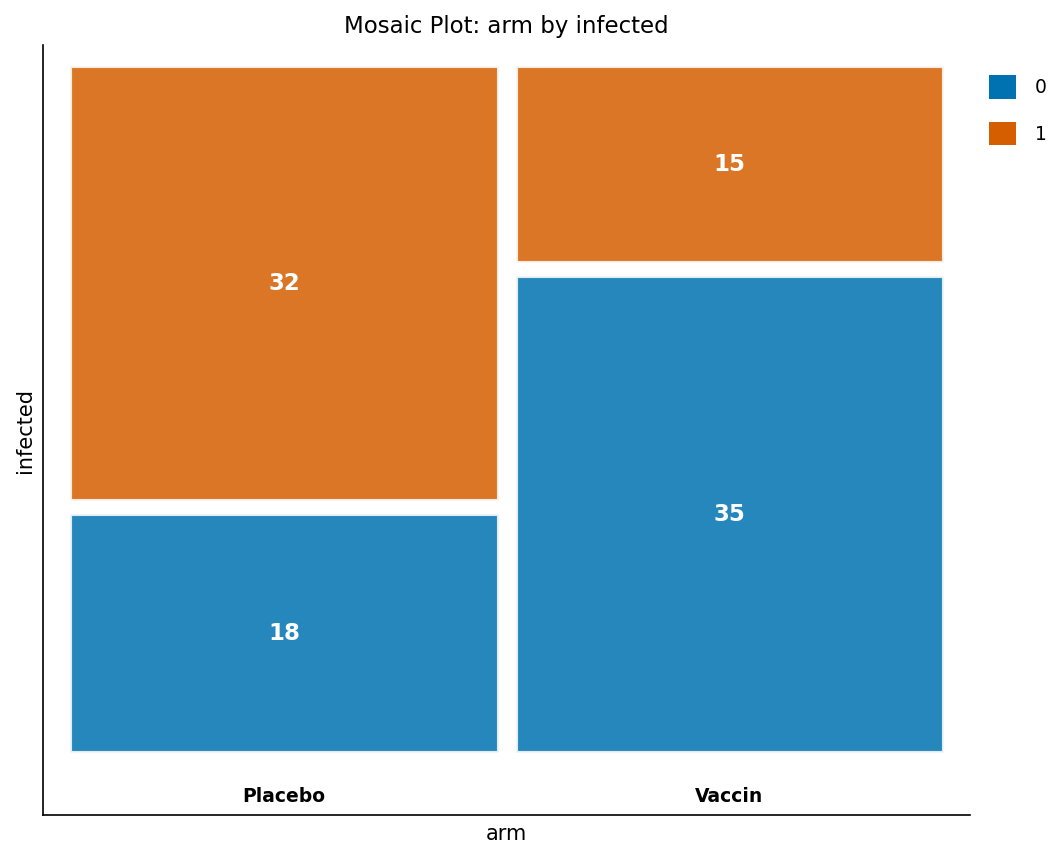

In [2]:
TITEL "Fyrfältstabell: attackfrekvens per arm";
PROCEDUR FREKVENSER data=trial;
    TABLES arm*infected / chisq relrisk riskdiff nocol nopercent;
    ETIKETT arm="Behandlingsarm" infected="Infektion";
KÖR;
TITEL;


## 3. Persontid och händelseantal per arm

Innan vi litar på den råa fyrfältstabellen kvantifierar vi uppföljningsobalansen. `PROC MEANS` rapporterar totala och genomsnittliga uppföljningsdagar plus infektionsantalet i varje arm. Om vaccinarmen ackumulerar *mer* persontid (färre tidiga händelser) underskattar den råa proportionen effekten — vilket är precis varför vi härnäst går över till en tid-till-händelse-modell.

In [3]:
TITEL "Persontid och händelseantal per arm";
PROCEDUR MEDELVÄRDEN data=trial n sum mean maxdec=2;
    KLASS arm;
    VARIABEL fu_days infected;
    ETIKETT arm="Behandlingsarm"
          fu_days="Uppföljningstid (dagar)"
          infected="Infektion";
KÖR;
TITEL;


                                          Persontid och händelseantal per arm                                           

                                                  The MEANS Procedure

                                  Analysis Variable : fu_days Uppföljningstid (dagar)

        Behandlingsarm          N Obs            Sum           Mean
        -----------------------------------------------------------
        Placebo                    50       14552.00         291.04
        Vaccin                     50       19438.00         388.76
        -----------------------------------------------------------

                                         Analysis Variable : infected Infektion

        Behandlingsarm          N Obs            Sum           Mean
        -----------------------------------------------------------
        Placebo                    50          32.00           0.64
        Vaccin                     50          15.00           0.30
        ------------------


NOTE: Option TITLE changed to Persontid och händelseantal per arm.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Kaplan-Meier-kurvor och log-rank-test

`PROC LIFETEST` skattar produktgräns- (Kaplan-Meier-) överlevnadsfunktionen — här sannolikheten att förbli infektionsfri över tid — separat för varje arm. `STRATA arm / test=(logrank wilcoxon)` begär de två standardhomogenitetstesten: **log-rank**-testet viktar alla händelsetider lika (mest kraftfullt under proportionella hazarder), medan **Wilcoxon** uppviktar tidiga händelser. Överensstämmelse mellan dem stödjer det antagande om proportionella hazarder som Cox-modellen kommer att förlita sig på. `ATRISK` anger antalet som fortfarande är i riskzonen.

                                     Kaplan-Meier: infektionsfri överlevnad per arm                                     

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       47
Censored                    53
Median Survival Time  427.5000

Stratum: Behandlingsarm = Placebo

                             N
--------------------  --------
Total                       50
Event                       32
Censored                    18
Median Survival Time  324.0000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  9.0000    0.9800     0.0198              50                 1
 17.0000    0.9600     0.0277              49                 1
 23.0000    0.9400     0.0336              48                 1
 26.0000    0.9200     0.0384              47       


NOTE: Option TITLE changed to Kaplan-Meier: infektionsfri överlevnad per arm.
NOTE: PROC LIFETEST data=trial

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


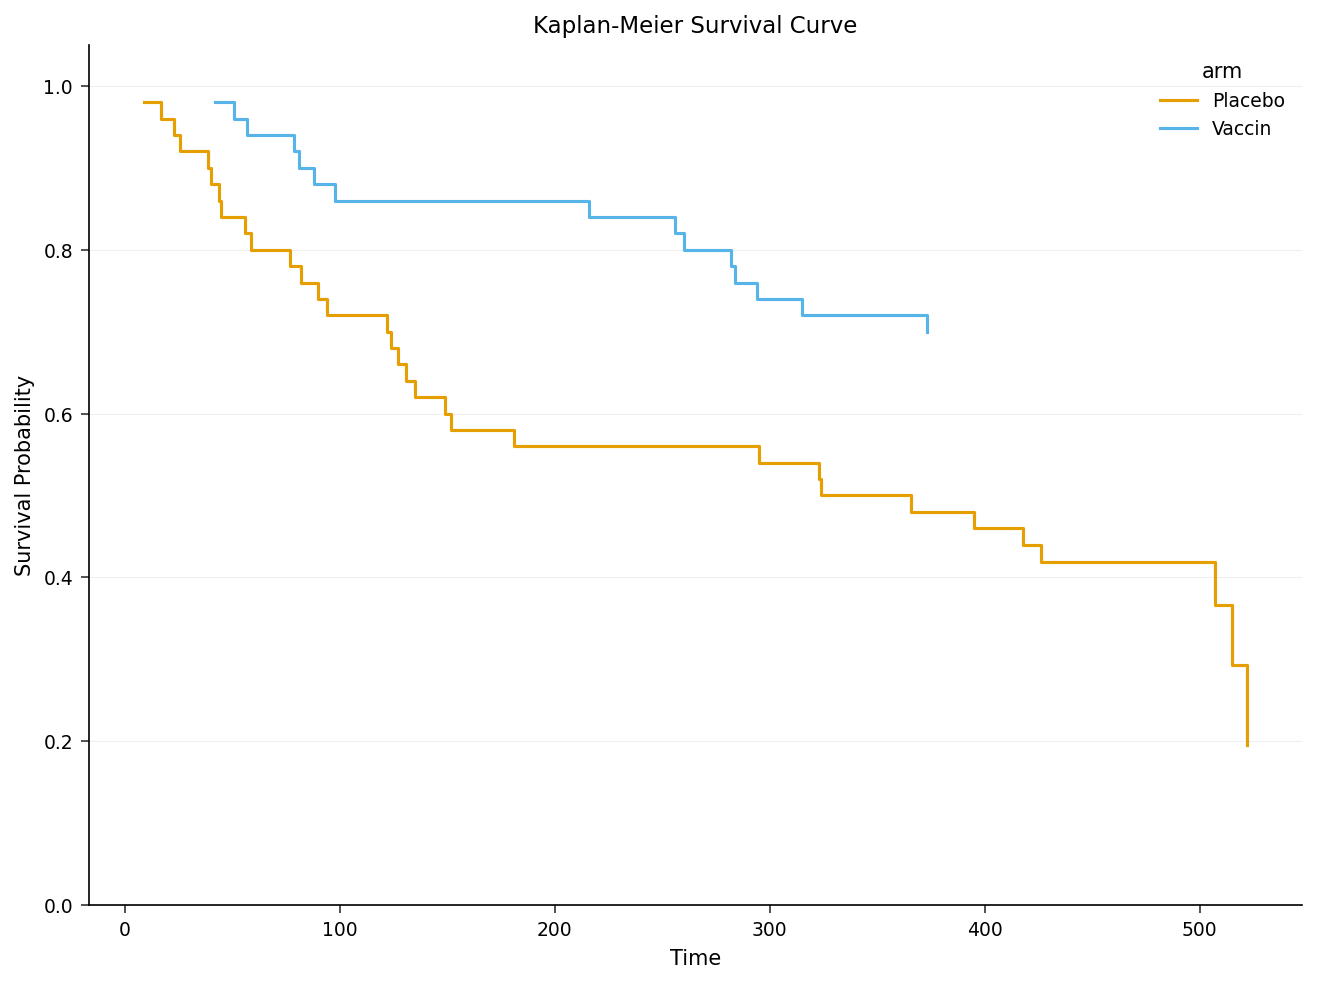

In [4]:
TITEL "Kaplan-Meier: infektionsfri överlevnad per arm";
PROCEDUR LIFETEST data=trial PLOTS=SURVIVAL atrisk;
    TIME fu_days*infected(0);
    STRATA arm / TEST=(logrank WILCOXON);
    ETIKETT arm="Behandlingsarm"
          fu_days="Uppföljningstid (dagar)";
KÖR;
TITEL;


## 5. Justerad Cox-modell och vaccineffekt

Cox proportionella hazardmodell ger den **justerade** hazardkvoten, kontrollerad för ålder, kön och exponeringsrisk vid baslinjen. `CLASS arm(ref='Placebo') sex(ref='M') / param=ref` sätter referenskodning så att `ARM`-koefficienten är den logaritmerade hazardkvoten för vaccin mot placebo. `TIES=EFRON` är den rekommenderade metoden för hantering av bindningar; `RL` skriver ut hazardkvotens konfidensgränser. `HAZARDRATIO`-satserna rapporterar armkontrasten (Wald-KI) och ålderseffekten per 10-årsökning.

**Vaccineffekten avläses direkt som `VE = 1 - HR` för armtermen**, och HR:s övre konfidensgräns motsvarar den nedre effektgräns som licensieringsbeslut vilar på.

In [5]:
TITEL "Justerad Cox-modell: vaccineffekt";
PROCEDUR PHREG data=trial;
    KLASS arm(REF='Placebo') sex(REF='M') / PARAM=REF;
    MODEL fu_days*infected(0) = arm AGE sex baseline_risk / TIES=efron rl;
    ETIKETT arm="Behandlingsarm"
          AGE="Ålder (år)"
          sex="Kön"
          baseline_risk="Högexponerat yrke"
          fu_days="Uppföljningstid (dagar)";
    hazardratio 'Vaccin mot Placebo' arm / cl=wald;
    hazardratio AGE / units=10;
KÖR;
TITEL;


                                           Justerad Cox-modell: vaccineffekt                                            

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 47
-2 LOG L                    368.882
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     29.0183         4      <.0001
Wald                 28.4562         4      <.0001
Score (Log-Rank)     30.6491         4      <.0001

                                        Analysis of Maximum Likelihood Estimates                                        

Parameter                 DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
------------------  --------  -------


NOTE: Option TITLE changed to Justerad Cox-modell: vaccineffekt.
NOTE: PROC PHREG data=trial

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## Tolkning

De tre lagren triangulerar till en enda effektslutsats:

- **Rå attackfrekvens (PROC FREQ).** Infektionsproportionen är **64 % i placebo (32/50) mot 30 % i vaccin (15/50)** — en riskdifferens på **-0.34** (95 % KI -0.524 till -0.156) och en oddskvot på **0.241** (95 % KI 0.105 till 0.556). Chi-två-testet förkastar oberoende (χ² = 11.60, p = 0.0007). Detta är den signal vid en första anblick som en granskare förväntar sig först — men den ignorerar den förskjutna, ojämna uppföljningen.

- **Persontid (PROC MEANS).** Genomsnittlig uppföljning är längre i vaccinarmen (**388.8 mot 291.0 dagar**) just eftersom färre deltagare lämnar tidigt via infektion (15 vaccinhändelser mot 32 placebo). Det bekräftar att den råa proportionen är en konservativ, uppföljningsförväxlad vy och motiverar tid-till-händelse-analysen.

- **Kaplan-Meier + log-rank (PROC LIFETEST).** Överlevnadskurvorna separerar tydligt — placebo når en **median infektionsfri tid på 324 dagar medan vaccinmedianen inte nås** (endast 15 av 50 vaccinerade blev någonsin infekterade). Båda homogenitetstesten förkastar likhet: **log-rank χ² = 11.25 (p = 0.0008)** och **Wilcoxon χ² = 9.11 (p = 0.0025)**. Deras överensstämmelse stödjer antagandet om proportionella hazarder som ligger till grund för Cox-modellen.

- **Justerad Cox-modell (PROC PHREG).** Efter justering för ålder, kön och exponeringsrisk vid baslinjen är hazardkvoten för vaccin mot placebo **0.369** med ett 95 % KI på **(0.198, 0.687)** helt under 1 (p = 0.0017), vilket ger en skattad **vaccineffekt på ungefär 63 %** (`VE = 1 - 0.369`). Den nedre effektgränsen (från HR:s övre konfidensgräns på 0.687) ligger nära **31 %**, vid kanten av den konventionella licensieringströskeln på 30-50 % — bred, som väntat för en studie med 100 försökspersoner. Yrke med hög exponering ungefär tredubblar infektionshazarden (**HR = 3.47**, 95 % KI 1.90-6.35, p < .0001), vilket bekräftar att kovariatjustering är motiverad; ålder (HR = 1.022 per år, p = 0.059) och kvinnligt kön (HR = 0.541, p = 0.064) har gränsfallseffekter som inte når signifikans på 0.05-nivån. Den globala nollhypotesen förkastas (likelihood-kvot χ² = 29.0, p < .0001).

**Slutsats.** Eftersom den råa fyrfältstabellen, de separerade Kaplan-Meier-kurvorna och den justerade Cox-skattningen alla pekar i samma riktning med konfidensintervall som utesluter ingen effekt, stödjer studien en effektsignal — även om de breda konfidensgränserna speglar det lilla urvalet. I en verklig ansökan skulle Cox-skattningen `1 - HR` och dess konfidensintervall — inte den råa proportionen — vara det primära effektmåttet, med utdata från FREQ och LIFETEST som det stödjande beskrivande och ickeparametriska bekräftelse som en säkerhetsövervakningskommitté (Data Safety Monitoring Board) granskar vid sidan av.